In [1]:
#pip install --trusted-host pypi.org --trusted-host files.pythonhosted.org scikit-posthocs

--- Starting Parametric Analysis: Scenarios vs SARIMA (Tukey HSD) ---
Scenarios loaded: 18 scenarios, 120 months
Scenario columns: ['CI', 'CII', 'CIII', 'CIV', 'CV']...
SARIMA columns before rename: ['Date', 'Projected_Consumption']
SARIMA data loaded: 120 months from 2026-01-01 00:00:00 to 2035-12-01 00:00:00
SARIMA columns after rename: ['Date', 'SARIMA']
Combined data shape: (120, 23)
Combined columns: ['Mes', 'Ano', 'Mes_Ano', 'CI_Pop_Uniforme', 'CII_Ambientalistas']...
Annual data aggregated: 10 years
Annual columns: ['Year', 'CI_Pop_Uniforme', 'CII_Ambientalistas', 'CIII_Perdularios', 'CIV_PopUnif_RendaLinear', 'CV_PopUnif_RendaEquilibrio', 'CVI_PopUnif_RendaDesequilibrio', 'CVII_PopAleat_RendaLinear', 'CVIII_PopAleat_RendaEquilibrio', 'CIX_PopAleat_RendaDesequilibrio', 'CX_Ambient_RendaLinear', 'CXI_Ambient_RendaEquilibrio', 'CXII_Ambient_RendaDesequilibrio', 'CXIII_Perdul_RendaLinear', 'CXIV_Perdul_RendaEquilibrio', 'CXV_Perdul_RendaDesequilibrio', 'CXVI_PopUnif_RendaAleatLinea


TUKEY HSD POST-HOC RESULTS (Baseline: SARIMA)
Scenario  Mean_Diff  p_adj  Significant
     CII -48,494.24 0.0421         True
    CIII -42,974.19 0.1363        False
  CXVIII -41,187.55 0.1892        False
   CXVII -40,720.96 0.2052        False
    CXVI -40,459.87 0.2146        False
      CI -34,870.71 0.4782        False
      CX -31,691.59 0.6567        False
    CXII -31,214.74 0.6826        False
     CXI -31,047.03 0.6916        False
     CVI  25,202.47 0.9266        False
      CV  25,187.94 0.9269        False
     CIX  25,125.19 0.9285        False
   CVIII  25,110.64 0.9288        False
     CIV  23,228.73 0.9645        False
    CVII  23,151.49 0.9656        False
   CXIII  -7,287.61 1.0000        False
     CXV  -5,967.49 1.0000        False
    CXIV  -6,159.76 1.0000        False

Results saved to: ..\resultados\tukey_sarima_comparison_summary.txt


Figure saved to: ..\resultados\tukey_sarima_differences.pdf


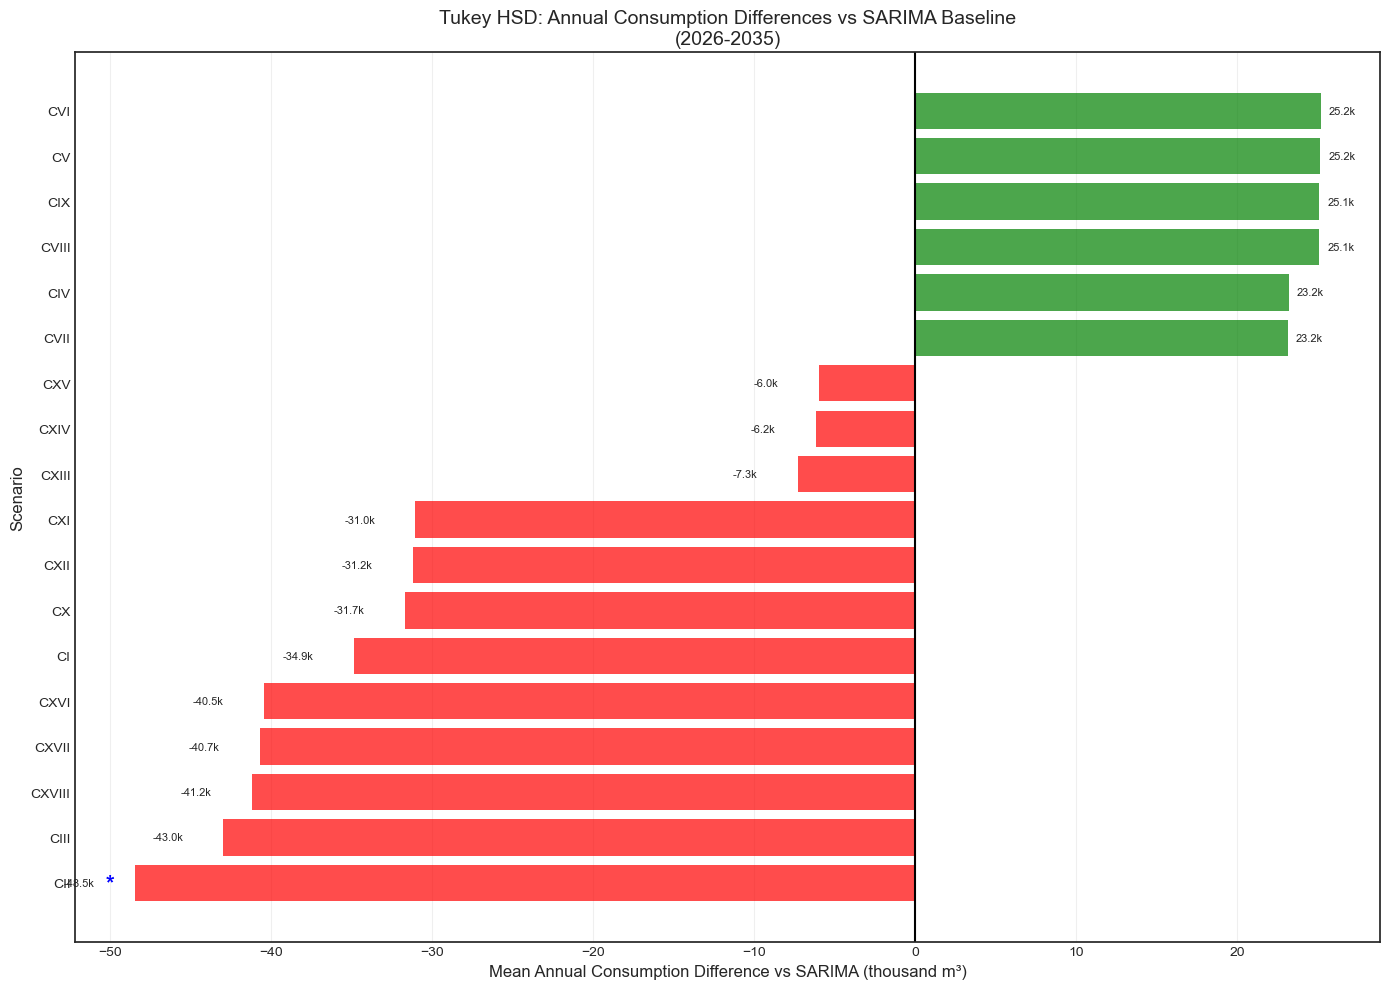


SUMMARY STATISTICS
Total scenarios analyzed: 18
Scenarios with Mean_Diff > 0 (higher than SARIMA): 6
Scenarios with Mean_Diff < 0 (lower than SARIMA): 12
Statistically significant differences (p < 0.05): 1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats.multitest as multi

# ==========================================
# 1. Configuration and Paths
# ==========================================

# Base project directory
BASE_PATH = '..' 

# Input Files
SCENARIO_FILE = 'consumo_previsto_todos_cenarios_2026_2035.csv'
SARIMA_FILE = 'previsao_consumo_sarima_2026_2035.csv'

# Directory Setup
INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')

# Ensure directories exist
for folder in [INPUT_DIR_RES]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Style configuration
try:
    plt.style.use('seaborn-v0_8-white')
except:
    try:
        plt.style.use('seaborn-white')
    except:
        plt.style.use('default')

sns.set_palette("husl")

def sum_yearly(df, date_col, value_cols):
    """ Helper function to aggregate monthly data into annual sums """
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()


def main():
    print("--- Starting Parametric Analysis: Scenarios vs SARIMA (Tukey HSD) ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    if not os.path.exists(path_scenarios):
        print(f"Error: Scenarios file not found at {path_scenarios}")
        return
    
    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    
    # Handle dates for scenarios
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')
    
    scenario_cols = [c for c in df_scenarios.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    df_scenarios = df_scenarios[df_scenarios['Date'] <= pd.to_datetime('2035-12-31')]
    
    print(f"Scenarios loaded: {len(scenario_cols)} scenarios, {len(df_scenarios)} months")
    print(f"Scenario columns: {[col.split('_')[0] for col in scenario_cols[:5]]}...")

    # Load SARIMA
    path_sarima = os.path.join(INPUT_DIR_MODELS, SARIMA_FILE)
    if not os.path.exists(path_sarima):
        print(f"Error: SARIMA file not found at {path_sarima}")
        return
    
    df_sarima = pd.read_csv(path_sarima)
    print(f"SARIMA columns before rename: {df_sarima.columns.tolist()}")
    
    df_sarima = df_sarima.rename(columns={'Date': 'Date', 'Projected_Consumption': 'SARIMA'})
    df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
    df_sarima = df_sarima[df_sarima['Date'] <= pd.to_datetime('2035-12-31')]
    
    print(f"SARIMA data loaded: {len(df_sarima)} months from {df_sarima['Date'].min()} to {df_sarima['Date'].max()}")
    print(f"SARIMA columns after rename: {df_sarima.columns.tolist()}")

    # Combine and aggregate
    df_combined = pd.merge(df_scenarios, df_sarima[['Date', 'SARIMA']], on='Date', how='inner')
    
    print(f"Combined data shape: {df_combined.shape}")
    print(f"Combined columns: {df_combined.columns.tolist()[:5]}...")
    
    all_series = scenario_cols + ['SARIMA']
    df_annual = sum_yearly(df_combined, 'Date', all_series)
    
    print(f"Annual data aggregated: {len(df_annual)} years")
    print(f"Annual columns: {df_annual.columns.tolist()}")
    
    # Check if SARIMA column exists
    if 'SARIMA' not in df_annual.columns:
        print("ERROR: 'SARIMA' column not found in annual data!")
        print(f"Available columns: {df_annual.columns.tolist()}")
        return

    # ==========================================
    # 3. Statistical Testing (ANOVA & Tukey)
    # ==========================================
    print("\n[1] PARAMETRIC ANALYSIS (ANOVA)")
    
    # Remove any rows with NaN values
    df_annual_clean = df_annual.dropna()
    
    if len(df_annual_clean) == 0:
        print("Error: No valid data after cleaning")
        return
    
    # Prepare data for ANOVA
    full_data_list = []
    for col in all_series:
        if col in df_annual_clean.columns:
            full_data_list.append(df_annual_clean[col])
        else:
            print(f"Warning: Column {col} not found in annual data")
    
    if len(full_data_list) < 2:
        print("Error: Not enough valid columns for ANOVA")
        return
    
    f_val, p_anova = stats.f_oneway(*full_data_list)
    
    print(f"ANOVA Results: F = {f_val:.4f}, p = {p_anova:.4f}")

    if p_anova < 0.05:
        # Prepare data for Tukey Post-Hoc
        values, groups = [], []
        for col in all_series:
            if col in df_annual_clean.columns:
                values.extend(df_annual_clean[col].tolist())
                if col == 'SARIMA':
                    group_label = 'SARIMA'
                else:
                    group_label = col.split('_')[0]
                groups.extend([group_label] * len(df_annual_clean))
            
        # Verify we have data
        print(f"\nPrepared {len(values)} values for {len(set(groups))} groups")
        
        tukey = pairwise_tukeyhsd(endog=values, groups=groups, alpha=0.05)
        tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
        
        # Filter: Comparisons involving SARIMA
        tukey_sarima = tukey_df[(tukey_df['group1'] == 'SARIMA') | (tukey_df['group2'] == 'SARIMA')].copy()
        
        if len(tukey_sarima) == 0:
            print("No comparisons with SARIMA found")
            return
        
        # Standardize view: Group A = SARIMA, Group B = Scenario
        def standardize(row):
            if row['group2'] == 'SARIMA':
                return pd.Series([row['group2'], row['group1'], -row['meandiff'], row['p-adj'], row['reject']])
            return pd.Series([row['group1'], row['group2'], row['meandiff'], row['p-adj'], row['reject']])

        standardized = tukey_sarima.apply(standardize, axis=1)
        standardized.columns = ['g1', 'g2', 'diff', 'padj', 'rej']
        
        tukey_final = standardized[['g2', 'diff', 'padj', 'rej']].rename(
            columns={'g2': 'Scenario', 'diff': 'Mean_Diff', 'padj': 'p_adj', 'rej': 'Significant'}
        ).sort_values(by='p_adj')
        
        # ==========================================
        # 4. Printing and Exporting Results
        # ==========================================
        
        # PRINT TO SCREEN
        print("\n" + "="*80)
        print("TUKEY HSD POST-HOC RESULTS (Baseline: SARIMA)")
        print("="*80)
        print(tukey_final.to_string(index=False, formatters={
            'Mean_Diff': '{:,.2f}'.format,
            'p_adj': '{:.4f}'.format
        }))
        print("="*80)

        # Save TXT
        txt_path = os.path.join(INPUT_DIR_RES, 'tukey_sarima_comparison_summary.txt')
        tukey_final.to_csv(txt_path, sep='\t', index=False)
        print(f"\nResults saved to: {txt_path}")
        
        # Create bar plot
        fig, ax = plt.subplots(figsize=(14, 10))
        
        tukey_sorted = tukey_final.sort_values('Mean_Diff')
        
        colors = ['red' if x < 0 else 'green' for x in tukey_sorted['Mean_Diff']]
        bars = ax.barh(range(len(tukey_sorted)), tukey_sorted['Mean_Diff'] / 1000, color=colors, alpha=0.7)
        ax.set_yticks(range(len(tukey_sorted)))
        ax.set_yticklabels(tukey_sorted['Scenario'])
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
        ax.set_xlabel('Mean Annual Consumption Difference vs SARIMA (thousand m³)', fontsize=12)
        ax.set_ylabel('Scenario', fontsize=12)
        ax.set_title('Tukey HSD: Annual Consumption Differences vs SARIMA Baseline\n(2026-2035)', fontsize=14)
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for i, (_, row) in enumerate(tukey_sorted.iterrows()):
            x_pos = row['Mean_Diff'] / 1000
            ax.text(x_pos + (0.5 if x_pos >= 0 else -2.5), i, 
                   f'{x_pos:.1f}k', ha='left' if x_pos >= 0 else 'right', 
                   va='center', fontsize=8)
            if row['Significant']:
                star_x = x_pos + (1.5 if x_pos >= 0 else -1.5)
                ax.text(star_x, i, '*', ha='center', va='center', 
                       fontsize=16, fontweight='bold', color='blue')
        
        plt.tight_layout()
        
        fig_path = os.path.join(INPUT_DIR_RES, 'tukey_sarima_differences.pdf')
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {fig_path}")
        plt.show()
        
        # Summary statistics
        print("\n" + "="*80)
        print("SUMMARY STATISTICS")
        print("="*80)
        print(f"Total scenarios analyzed: {len(scenario_cols)}")
        print(f"Scenarios with Mean_Diff > 0 (higher than SARIMA): {len(tukey_final[tukey_final['Mean_Diff'] > 0])}")
        print(f"Scenarios with Mean_Diff < 0 (lower than SARIMA): {len(tukey_final[tukey_final['Mean_Diff'] < 0])}")
        print(f"Statistically significant differences (p < 0.05): {len(tukey_final[tukey_final['Significant'] == True])}")
        
    else:
        print("ANOVA not significant. Skipping Tukey HSD.")

if __name__ == "__main__":
    main()